<a href="https://colab.research.google.com/github/Rakmik/NM/blob/main/%D0%9B%D0%A0%E2%84%963_2_%D0%97%D0%B0%D0%B3%D0%B8%D0%BD%D0%B0%D0%B9%D0%BA%D0%BE_%D0%9F%D0%B0%D0%B2%D0%BB%D0%BE_%D0%A4%D0%86%D0%A2_2_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 3

Варіант 8

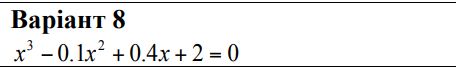

In [1]:
!pip install numdifftools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 3.8 MB/s eta 0:00:00


In [2]:
import numdifftools as nd

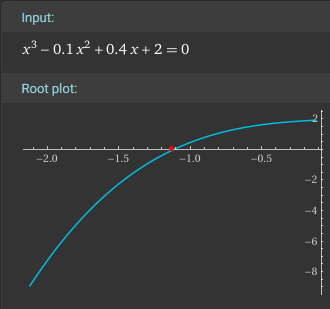

Визначаємо, що корінь належить відрізку [-2,-1]

In [18]:
def f(x: float):
    return x**3 - 0.1*x**2 + 0.4*x + 2

def fprime(x: float):
    return nd.Derivative(f, n=1)

def phi(x: float):
    # c = -0.1 (забезпечує |phi'(x)|<1 на [-2,-1])
    c = -0.1
    return x + c * f(x)

def iterate_fixed_point(x0: float, iters: int = 5):
    xs = [x0]
    x = x0
    for _ in range(iters):
        x = phi(x)
        xs.append(x)
    return xs

def error_bound(x_last: float) -> float:
    # Для Варіанта 8: μ = min_{x∈[-2,-1]} |f'(x)| = 3.6
    mu = 3.6
    return abs(f(x_last)) / mu

In [19]:
def main():
    x0 = -1.0 # нульове наближення має належати відрізку [-2, -1]

    iters = 5
    xs = iterate_fixed_point(x0, iters)

    print("Fixed-point iteration for f(x) = x^3 - x + 7 with phi(x) = x - 0.1*f(x)")
    print(f"Interval: [-3, -1], start x0 = {x0}")

    for i, xi in enumerate(xs):
        if i == 0:
            print(f"x_{i} = {xi:.10f}")
        else:
            print(f"x_{i} = phi(x_{i-1}) = {xi:.10f}")
    bound = error_bound(xs[-1])
    print("\nError bound after 5 iterations:  |ξ - x5| ≤ |f(x5)| / μ")
    print(f"f(x5) = {f(xs[-1]):.10f},  μ = 2  ⇒  |ξ - x5| ≤ {bound:.10f}")
    return xs[-1], bound

if __name__ == "__main__":
    root_approx, bound = main()

Fixed-point iteration for f(x) = x^3 - x + 7 with phi(x) = x - 0.1*f(x)
Interval: [-3, -1], start x0 = -1.0
x_0 = -1.0000000000
x_1 = phi(x_0) = -1.0500000000
x_2 = phi(x_1) = -1.0812125000
x_3 = phi(x_2) = -1.0998778408
x_4 = phi(x_3) = -1.1107297534
x_5 = phi(x_4) = -1.1169303413

Error bound after 5 iterations:  |ξ - x5| ≤ |f(x5)| / μ
f(x5) = 0.0350666328,  μ = 2  ⇒  |ξ - x5| ≤ 0.0097407313


Спрощений варіант коду

In [20]:
# Рівняння: f(x) = x**3 - 0.1*x**2 + 0.4*x + 2
# Ітераційна функція: φ(x) = x - 0.1 * f(x)  (c = -0.1)
# Початкове наближення: x0 = -1
# Кількість ітерацій: 5
# Оцінка похибки: |ξ - x5| ≤ |f(x5)| / μ, де μ = min_{[-2,-1]} |f'(x)| = 2

def f(x):
    return x**3 - 0.1*x**2 + 0.4*x + 2

def phi(x):
    return x - 0.1 * f(x)   # c = -0.1

def fixed_point(x0=-1.0, iters=5):
    xs = [x0]
    for _ in range(iters):
        xs.append(phi(xs[-1]))
    return xs

# Запуск і вивід результатів
xs = fixed_point(-1.0, 5)

for i, xi in enumerate(xs):
    print(f"x_{i} = {xi:.10f}")

# Похибка методу простої ітерації після 5-ї ітерації
mu = 3.6                      # μ = min_{[-3,-1]} |3x^2 - 1| = 2
err_bound = abs(f(xs[-1]))/mu
print(f"\nОцінка похибки: |ξ - x5| ≤ {err_bound:.10f}")

x_0 = -1.0000000000
x_1 = -1.0500000000
x_2 = -1.0812125000
x_3 = -1.0998778408
x_4 = -1.1107297534
x_5 = -1.1169303413

Оцінка похибки: |ξ - x5| ≤ 0.0097407313


Перевірка

In [12]:
import sympy as sym

x = sym.symbols('x')

f = x**3 - 0.1*x**2 + 0.4*x + 2

# точні корені
s = sym.solve(f, x)
print(s)

# числові корені
print(sym.nroots(f))

[-1.12491165464394, 0.612455827321968 - 1.18440502185592*I, 0.612455827321968 + 1.18440502185592*I]
[-1.12491165464394, 0.612455827321968 - 1.18440502185592*I, 0.612455827321968 + 1.18440502185592*I]
